In [194]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np



In [195]:
# Define texts and labels (from WC119BP8nKKu)
texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever"
]

In [196]:
labels=np.array([1,1,1,1,0,0,0,0])

In [197]:

vocab_size = 1000
max_length = 6

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<oov>")

# Learn all unique words from the dataset and assign an integer ID to each word
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

x = pad_sequences(sequences, maxlen=max_length, padding="post")

# Create a dictionary:
# word -> integer ID
print("Word Index:")
print(tokenizer.word_index)

# Convert each sentence into a sequence of numbers based on the word index
sequences = tokenizer.texts_to_sequences(texts)
print("\nSequences:")
print(x)

Word Index:
{'<oov>': 1, 'this': 2, 'i': 3, 'movie': 4, 'film': 5, 'very': 6, 'acting': 7, 'story': 8, 'love': 9, 'is': 10, 'amazing': 11, 'good': 12, 'excellent': 13, 'hate': 14, 'terrible': 15, 'boring': 16, 'worst': 17, 'ever': 18}

Sequences:
[[ 3  9  2  4  0  0]
 [ 2  5 10 11  0  0]
 [ 6 12  7  0  0  0]
 [13  8  0  0  0  0]
 [ 3 14  2  4  0  0]
 [15  5  0  0  0  0]
 [ 6 16  8  0  0  0]
 [17  7 18  0  0  0]]


In [198]:
class TokenAndPositionEmbedding(layers.Layer): #1
    def __init__(self, max_length, vocab_size, embed_dim):
        super().__init__()
        # token embeding
        self.token_embedding = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )
          #positional embedding
        self.position_embedding = layers.Embedding(
            input_dim=max_length,
            output_dim=embed_dim
        )
 
    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        token_emb = self.token_embedding(x)
        position_emb = self.position_embedding(positions)
        return token_emb + position_emb

Token Embedding

what: Turns each word ID into a 16-number vector the model can actually work with.
why: Numbers like 3 and 9 mean nothing on their own. Vectors let the model learn that 'hate' and 'terrible' are similar.
without: The model treats word IDs like prices — word 9 seems bigger than word 3. Completely wrong.

Positional Embedding

what: Adds position information to each word so the model knows word 1 came before word.
why: Transformers read all words at once, not one by one. Without this, they have no idea what comes first.
without: I love this movie' and 'movie this love I' look exactly the same to the model.

In [199]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        #multi head attention 
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )
  
            #Feed-Forward Network
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
 
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()
 
    def call(self, inputs):
        # Self-attention (Query, Key, Value are calculated here using the same input)
        # The attention layer takes the input and computes
        # attention scores to capture relationships between different positions in the sequence.
        attention_output = self.attention(inputs, inputs)
 
        # Add + Normalize
        out1 = self.layernorm1(inputs + attention_output)
 
        # Feed-forward network
        ffn_output = self.ffn(out1)
 
        # Add + Normalize
        out2 = self.layernorm2(out1 + ffn_output)
 
        return out2

 Multi-Head Attention
 
 what: Lets every word look at every other word and decide how much to focus on each one.
 why: Context matters. The word 'not' completely changes the meaning of 'good' — attention catches that.
 without: Each word is processed in a bubble. 'not good' and 'good' become indistinguishable.

 Feed-Forward Network

 what: Two Dense layers applied to each token independently: expands 16 → 32 dims with ReLU activation, then compresses back 32 → 16.
why: Attention captures WHICH tokens relate to each other. The FFN extracts WHAT those relationships mean by applying non-linear transformations to each token.
without: The model can only compute weighted sums of token vectors, which are purely linear operations. It cannot learn complex non-linear patterns needed to distinguish sentiment.

 Add & Normalize
        
 what: Adds the original layer input back to the layer output (residual connection), then applies LayerNormalization to rescale activations to mean=0 and std=1.
 why: Residual connections prevent vanishing gradients so information flows freely during backpropagation. LayerNorm keeps activations stable so training converges faster.
 without: Gradients shrink to near-zero in deeper layers. Training becomes unstable or fails to converge. Useful information from earlier layers gets lost.
    

In [200]:
# build the model
embed_dim = 16
num_heads = 2
ff_dim = 32

inputs = layers.Input(shape=(max_length,))

embedding_out = TokenAndPositionEmbedding(
    max_length=max_length,
    vocab_size=vocab_size,
    embed_dim=embed_dim
)(inputs)

transformer_out = TransformerBlock(
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim
)(embedding_out)

#Output Layer

pooled = layers.GlobalAveragePooling1D()(transformer_out)

outputs = layers.Dense(1, activation="sigmoid")(pooled)

model = tf.keras.Model(inputs=inputs, outputs=outputs)


6. Output Layer

 what: Averages all word vectors into one, then squashes it to a number between 0 and 1.
 why: You need one clear answer — positive or negative. Sigmoid gives exactly that.
 without: The model spits out a jumble of numbers with no way to make a final decision.

In [201]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_115"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_114 (InputLayer)    │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_57 │ (None, 6, 16)          │        16,096 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_57            │ (None, 6, 16)          │         3,296 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_57     │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,409 (75.82 KB)

 Trainable params: 19,409 (75.82 KB)

 Non-trainable params: 0 (0.00 B)

In [202]:
print(type(x))
print(x.shape)
print(type(labels))
print(labels.shape)

<class 'numpy.ndarray'>
(8, 6)
<class 'numpy.ndarray'>
(8,)


In [203]:
model.fit(
    x,        # ← lowercase, matches pad_sequences output above
    labels,
    epochs=30,
    batch_size=2,
    verbose=1
)
 

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5000 - loss: 0.7985
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 0.8066
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5000 - loss: 0.6813 
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6250 - loss: 0.6686
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5000 - loss: 0.6392
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.5773
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.5303
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.5234
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.4946 
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.4613
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.4252 
Epoch 12/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.3960 
E

In [207]:
import time
import pandas as pd

results = []

for num_heads in [1, 2, 4, 8]:
    for embed_dim in [8, 16, 32, 64]:

        inputs = layers.Input(shape=(max_length,))
        
        embedding_out = TokenAndPositionEmbedding(
            max_length=max_length,
            vocab_size=vocab_size,
            embed_dim=embed_dim
        )(inputs)
        
        transformer_out = TransformerBlock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=32
        )(embedding_out)
        
        pooled = layers.GlobalAveragePooling1D()(transformer_out)
        outputs = layers.Dense(1, activation="sigmoid")(pooled)
        
        model = tf.keras.Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

        start = time.time()
        history = model.fit(x, labels, epochs=30, batch_size=2, verbose=0)
        end = time.time()

        results.append({
            "Heads"         : num_heads,
            "Embedding Dim" : embed_dim,
            "Accuracy (%)"  : round(history.history["accuracy"][-1] * 100, 2),
            "Training Time" : round(end - start, 2)
        })

df = pd.DataFrame(results)
print(df.to_string(index=False))

 Heads  Embedding Dim  Accuracy (%)  Training Time
     1              8         100.0           4.21
     1             16         100.0           3.76
     1             32         100.0           5.17
     1             64         100.0           3.99
     2              8         100.0           3.77
     2             16         100.0           3.68
     2             32         100.0           4.12
     2             64         100.0           3.91
     4              8         100.0           3.66
     4             16         100.0           3.55
     4             32         100.0           4.62
     4             64         100.0           3.76
     8              8         100.0           4.05
     8             16         100.0           3.86
     8             32         100.0           3.75
     8             64         100.0           3.59


In [205]:
test_sentences = [
    "I love the film",
    "This movie was awful"
    "waht is the movie about"
    "His is rockstar"
]
test_seq = tokenizer.texts_to_sequences(test_sentences)
test_pad = pad_sequences(test_seq, maxlen=max_length, padding="post")
predictions = model.predict(test_pad)
 
for sentence, prediction in zip(test_sentences, predictions):
    print(sentence, "->", prediction[0])
    if prediction[0] > 0.5:
        print("Prediction: Positive")
    else:
        print("Prediction: Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
I love the film -> 0.9521048
Prediction: Positive
This movie was awfulwaht is the movie aboutHis is rockstar -> 0.9824104
Prediction: Positive


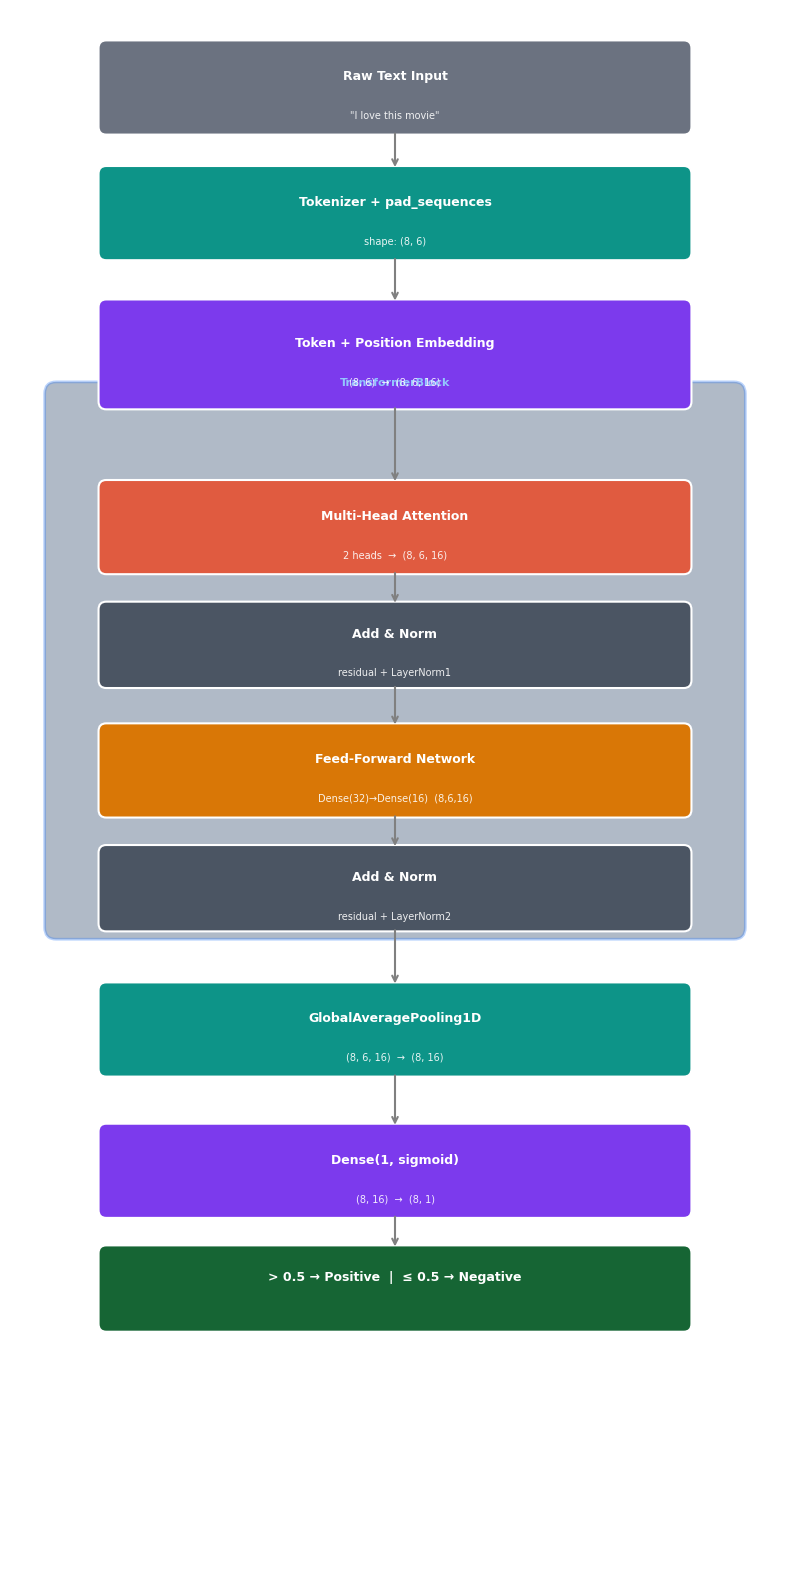

In [206]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(8, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')

def draw_box(ax, x, y, w, h, label, sublabel, color, text_color='white'):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor='white', linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y + 0.15, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color=text_color)
    if sublabel:
        ax.text(x, y - 0.35, sublabel, ha='center', va='center',
                fontsize=7, color=text_color, alpha=0.9)

def draw_arrow(ax, x, y1, y2):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

cx = 5  # center x

# ── Boxes: (label, sublabel, y, height, color)
steps = [
    ("Raw Text Input",              '"I love this movie"',         19,   1.0,  '#6b7280'),
    ("Tokenizer + pad_sequences",   "shape: (8, 6)",               17.4, 1.0,  '#0d9488'),
    ("Token + Position Embedding",  "(8, 6)  →  (8, 6, 16)",      15.6, 1.2,  '#7c3aed'),
    ("Multi-Head Attention",        "2 heads  →  (8, 6, 16)",      13.4, 1.0,  '#e05b40'),
    ("Add & Norm",                  "residual + LayerNorm1",        11.9, 0.9,  '#4b5563'),
    ("Feed-Forward Network",        "Dense(32)→Dense(16)  (8,6,16)",10.3, 1.0, '#d97706'),
    ("Add & Norm",                  "residual + LayerNorm2",        8.8,  0.9,  '#4b5563'),
    ("GlobalAveragePooling1D",      "(8, 6, 16)  →  (8, 16)",      7.0,  1.0,  '#0d9488'),
    ("Dense(1, sigmoid)",           "(8, 16)  →  (8, 1)",          5.2,  1.0,  '#7c3aed'),
    ("> 0.5 → Positive  |  ≤ 0.5 → Negative", "",   3.7,  0.9,  '#166534'),
]

# Transformer block boundary
tb_box = FancyBboxPatch((0.6, 8.3), 8.8, 6.8,
                        boxstyle="round,pad=0.15",
                        facecolor='#1e3a5f', edgecolor='#3b82f6',
                        linewidth=2, alpha=0.35)
ax.add_patch(tb_box)
ax.text(5, 15.25, 'TransformerBlock', ha='center', va='center',
        fontsize=8, fontweight='bold', color='#93c5fd')

# Draw all boxes and arrows
for i, (label, sublabel, y, h, color) in enumerate(steps):
    draw_box(ax, cx, y, 7.5, h, label, sublabel, color)
    if i < len(steps) - 1:
        next_y = steps[i+1][2]
        gap_top = y - h/2
        gap_bot = next_y + steps[i+1][3]/2
        mid = (gap_top + gap_bot) / 2
        draw_arrow(ax, cx, gap_top - 0.05, gap_bot + 0.05)

plt.tight_layout()
plt.savefig('transformer_flow.png', dpi=150, bbox_inches='tight',
            facecolor='#111827')
plt.show()